In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import fsolve, brentq
from scipy.linalg import eigvals as speigvals
import warnings
import time
from collections import Counter

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'Arial'

# ── Base parameters (Yang et al. 2023) ───────────────────────────────────────
CFG_BASE = {
    'S1': 0.0,  'S2': 1.0,  'S3': 1.0,   # S1 will be set by L
    'd_aSyn': 15.0, 'K': 8.5, 'n': 4.0,
    'k1': 0.72,  'k2': 0.72,
    'k3': 0.7,   'k4': 0.7,  'k5': 2.7,
    'k6': 1.0,   'k7': 0.5,  'k8': 1.0,  'ERST': 2.0,
    'k9': 2.0,   'k10': 10.0,'k11': 0.4, 'k12': 7.0,  'mTORT': 1.0,
    'k13': 2.0,  'k14': 4.0, 'k15': 1.0,
    'k16': 10.0, 'k17': 0.6, 'Jbe': 1.0, 'Beclin1T': 1.0,
    'k18': 1.0,  'k19': 2.0, 'k20': 2.0,
    'k21': 2.0,  'k22': 4.5, 'Jca': 0.04,'CaspasesT': 1.0,
}

# ── Transport ─────────────────────────────────────────────────────────────────
TR = {
    'DROS':      6.5e6,
    'DERS':      3.6e4,
    'DmTOR':     36.0,
    'DBeclin1':  5.4e4,
    'DCaspases': 7.2e4,
    'vlyso':     7200.0,
    'vB':        36.0,
    'vC':        36.0,
}

# ── S1(L) = S1_base + alpha * L ───────────────────────────────────────────────
# Biological basis: longer axons house more mitochondria in total,
# producing more cumulative ROS over the neuron's lifetime.
# alpha units: µM⁻¹ · µm⁻¹ (oxidative stress per unit length)
# Calibrated so that L=1000 µm gives S1 in the bistable window
# when S1_base is near zero.

S1_BASE  = 0.0       # basal oxidative stress (age/genetics independent)
ALPHA    = 0.001     # length scaling: S1 increases by 0.001 per µm
                     # → at L=1000: S1 = 0.0 + 0.001*1000 = 1.0
                     # → at L=200:  S1 = 0.0 + 0.001*200  = 0.2
                     # → at L=1500: S1 = 0.0 + 0.001*1500 = 1.5

def S1_of_L(L, S1_base=S1_BASE, alpha=ALPHA):
    return S1_base + alpha * L

# ── Single axon for this notebook ────────────────────────────────────────────
L   = 1000.0
Nx  = 100
dx  = L / Nx
x   = np.linspace(0, L, Nx)

# Effective S1 at L=1000
S1_eff = S1_of_L(L)
print(f"L = {L} µm")
print(f"S1(L) = {S1_BASE} + {ALPHA} × {L} = {S1_eff:.4f}")
print(f"\nS1 at different lengths:")
for Ltest in [200, 500, 750, 1000, 1500]:
    print(f"  L={Ltest:5.0f} µm → S1 = {S1_of_L(Ltest):.3f}")

species_names = ['ROS', 'aSyn*', 'ERS', 'mTOR', 'Beclin1', 'Caspases']
SS_HEALTHY = {
    'ROS': 2.493, 'aSyn': 1.815, 'ERS': 0.952,
    'mTOR': 0.668, 'Beclin1': 0.762, 'Caspases': 0.118,
}

L = 1000.0 µm
S1(L) = 0.0 + 0.001 × 1000.0 = 1.0000

S1 at different lengths:
  L=  200 µm → S1 = 0.200
  L=  500 µm → S1 = 0.500
  L=  750 µm → S1 = 0.750
  L= 1000 µm → S1 = 1.000
  L= 1500 µm → S1 = 1.500


In [2]:
def yang_ode_pure(t, y, p):
    ROS, A, ERS, mTOR, B1, Casp = [max(v, 0.0) for v in y]
    Hill  = (A/p['K'])**p['n'] / (1 + (A/p['K'])**p['n'])
    dROS  = p['k1']*(1+p['S1']+p['d_aSyn']*Hill) - p['k2']*ROS*p['S2']
    dA    = p['k3']*ROS*p['S3'] - p['k4']*p['k5']*A*B1*mTOR
    dERS  = p['k6']*A*p['k7']*(p['ERST']-ERS) - p['k8']*ERS
    MT    = p['mTORT']
    dM    = (p['k9']+p['k10']*ERS)*(MT-mTOR) - (p['k11']+p['k12']*B1)*mTOR
    BT    = p['Beclin1T']
    act_B = (p['k13']+p['k14']*ERS)*(BT-B1)/(p['Jbe']+BT-B1+1e-12)
    inh_B = (p['k15']+p['k16']*Casp+p['k17']*mTOR)*B1/(p['Jbe']+B1+1e-12)
    dB1   = act_B - inh_B
    CT    = p['CaspasesT']
    act_C = (p['k18']+p['k19']*ERS+p['k20']*mTOR)*(CT-Casp)/(p['Jca']+CT-Casp+1e-12)
    inh_C = (p['k21']+p['k22']*B1)*Casp/(p['Jca']+Casp+1e-12)
    dCasp = act_C - inh_C
    return [dROS, dA, dERS, dM, dB1, dCasp]


def numerical_jacobian(fp, p, eps=1e-6):
    n  = len(fp)
    J  = np.zeros((n, n))
    f0 = np.array(yang_ode_pure(0, fp, p))
    for j in range(n):
        yp = fp.copy(); yp[j] += eps
        J[:, j] = (np.array(yang_ode_pure(0, yp, p)) - f0) / eps
    return J


def find_all_stable_fps(p, n_seeds=1500, tol=1e-8):
    """Find all stable fixed points at parameter set p."""
    def rhs(y): return yang_ode_pure(0, y, p)

    fps = []
    rng = np.random.default_rng(42)
    seeds = rng.uniform(
        low  = [0, 0,  0, 0, 0, 0],
        high = [20, 20, 2, 1, 1, 1],
        size = (n_seeds, 6)
    )

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        for s in seeds:
            try:
                fp, info, ier, _ = fsolve(rhs, s, full_output=True)
                if ier != 1: continue
                if np.max(np.abs(rhs(fp))) > tol: continue
                if np.any(fp < -1e-4): continue
                is_new = all(
                    not np.allclose(fp, e['fp'], atol=1e-3)
                    for e in fps
                )
                if is_new:
                    J      = numerical_jacobian(fp, p)
                    eigs   = speigvals(J)
                    stable = np.max(np.real(eigs)) < 0
                    if stable:
                        fps.append({'fp': fp, 'A': fp[1],
                                    'B1': fp[4], 'C': fp[5]})
            except:
                continue

    fps = sorted(fps, key=lambda d: d['A'])
    labels = ['Healthy', 'Intermediate', 'Disease']
    for i, fd in enumerate(fps):
        fd['label'] = labels[i] if i < 3 else f'State{i}'
    return fps


def run_ode_to_ss(p, ic, T=800):
    """Run Yang ODE to steady state from IC."""
    sol = solve_ivp(yang_ode_pure, (0, T), ic,
                    args=(p,), method='Radau',
                    rtol=1e-9, atol=1e-11,
                    dense_output=False)
    return sol.y[:, -1]


def classify_by_Asyn(A_val, stable_fps):
    """Classify a value by proximity to FP aSyn* levels."""
    if not stable_fps:
        return 'Unknown'
    nearest = min(stable_fps, key=lambda fp: abs(A_val - fp['A']))
    return nearest['label']


print("ODE utilities defined.")

ODE utilities defined.


In [3]:
# ── Reference FPs at tristable S1=1.462 ──────────────────────────────────────
print("Finding reference FPs at S1=1.462...")
p_ref = {**CFG_BASE, 'S1': 1.462, 'S2': 1.0, 'S3': 1.0}
fps_ref = find_all_stable_fps(p_ref)

print(f"\nReference FPs (S1=1.462, S2=1, S3=1):")
print(f"{'Label':<16}  {'aSyn*':>8}  {'Beclin1':>8}  {'Caspases':>10}")
print("─" * 50)
for fp in fps_ref:
    print(f"  {fp['label']:<14}  {fp['A']:>8.4f}  "
          f"{fp['B1']:>8.4f}  {fp['C']:>10.4f}")

# ── FPs at effective S1(L=1000) ───────────────────────────────────────────────
print(f"\nFinding FPs at effective S1={S1_eff:.4f} (L=1000 µm)...")
p_eff = {**CFG_BASE, 'S1': S1_eff, 'S2': 1.0, 'S3': 1.0}
fps_eff = find_all_stable_fps(p_eff)

print(f"\nFPs at S1={S1_eff:.4f} (S2=1, S3=1):")
print(f"{'Label':<16}  {'aSyn*':>8}  {'Beclin1':>8}  {'Caspases':>10}")
print("─" * 50)
for fp in fps_eff:
    print(f"  {fp['label']:<14}  {fp['A']:>8.4f}  "
          f"{fp['B1']:>8.4f}  {fp['C']:>10.4f}")

if len(fps_eff) < 2:
    print(f"\n⚠ Only {len(fps_eff)} stable FP at S1={S1_eff:.3f}.")
    print("  Increase ALPHA or S1_BASE in Cell 1.")
    print("  Try ALPHA=0.0015 → S1(1000)=1.5 for tristability.")

Finding reference FPs at S1=1.462...

Reference FPs (S1=1.462, S2=1, S3=1):
Label                aSyn*   Beclin1    Caspases
──────────────────────────────────────────────────
  Healthy           1.8150    0.7621      0.1179
  Intermediate      3.7083    0.3558      0.9243
  Disease          16.4825    0.4343      0.9388

Finding FPs at effective S1=1.0000 (L=1000 µm)...

FPs at S1=1.0000 (S2=1, S3=1):
Label                aSyn*   Beclin1    Caspases
──────────────────────────────────────────────────
  Healthy           1.4992    0.7704      0.0941
  Intermediate      2.9112    0.3360      0.9196
  Disease          15.9256    0.4333      0.9386


In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# SWEEP ALL THREE PARAMETERS TO FIND STATE BOUNDARIES AT L=1000 µm
#
# For each parameter sweep, three ICs seed the three basins.
# We record which stable FP each IC converges to.
# ══════════════════════════════════════════════════════════════════════════════

# Three basin-seeding ICs (from reference FPs + noise)
def make_ic_seeds(fps_ref, noise=0.05):
    """Build one IC per reference FP, with small noise."""
    seeds = []
    for fp in fps_ref:
        ic = fp['fp'] + np.random.default_rng(0).uniform(
            -noise, noise, 6) * fp['fp']
        ic = np.maximum(ic, 1e-6)
        seeds.append(ic)
    return seeds

# Fallback ICs if fewer than 3 FPs found
FALLBACK_ICS = [
    [0.5,  0.5,  0.1, 0.5, 0.7, 0.01],   # healthy seed
    [2.0,  3.5,  0.8, 0.7, 0.4, 0.85],   # intermediate seed
    [5.0, 12.0,  1.5, 0.8, 0.4, 0.90],   # disease seed
]
IC_LABELS = ['Seed→Healthy', 'Seed→Intermediate', 'Seed→Disease']


def param_sweep(param_name, param_vals, base_cfg,
                ic_seeds, T=800, verbose=True):
    """
    Sweep one parameter and record SS aSyn* from three ICs.
    Returns dict keyed by IC label.
    """
    results = {lbl: {'param': [], 'A_ss': [], 'B1_ss': [],
                     'Casp_ss': [], 'state': []}
               for lbl in IC_LABELS}

    n_total = len(param_vals) * len(ic_seeds)
    count   = 0

    for val in param_vals:
        p = {**base_cfg, param_name: val}

        for lbl, ic in zip(IC_LABELS, ic_seeds):
            ss = run_ode_to_ss(p, ic, T=T)

            # Find FPs at this parameter value for classification
            fps_here = find_all_stable_fps(p, n_seeds=400)
            state    = classify_by_Asyn(ss[1], fps_here)

            results[lbl]['param'].append(val)
            results[lbl]['A_ss'].append(ss[1])
            results[lbl]['B1_ss'].append(ss[4])
            results[lbl]['Casp_ss'].append(ss[5])
            results[lbl]['state'].append(state)
            count += 1

        if verbose and count % (3*5) == 0:
            pct = count / n_total * 100
            print(f"  {param_name}={val:.3f}  |  {pct:.0f}%", end='\r')

    print(f"\n  {param_name} sweep done. ({count} runs)")
    return results


# ── Build ICs from reference FPs ─────────────────────────────────────────────
if len(fps_ref) >= 3:
    ic_seeds = make_ic_seeds(fps_ref)
    print("Using FP-based IC seeds.")
else:
    ic_seeds = FALLBACK_ICS
    print("Using fallback IC seeds.")

NameError: name 'L_values' is not defined

In [5]:
# ── S1 sweep — with S1(L) model ──────────────────────────────────────────────
# S1 here means S1_base; alpha is fixed.
# S1_eff(L) = S1_base + alpha*L
# We sweep S1_base from -2 to 3, so S1_eff(1000) = S1_base + 1.0

S1_base_vals = np.linspace(-2.0, 3.0, 80)
# Convert to effective S1 at L=1000
S1_eff_vals  = S1_base_vals + ALPHA * L

print(f"S1 sweep: S1_base ∈ [{S1_base_vals[0]:.1f}, {S1_base_vals[-1]:.1f}]")
print(f"→ Effective S1(L=1000) ∈ [{S1_eff_vals[0]:.2f}, {S1_eff_vals[-1]:.2f}]")
print(f"Running {len(S1_base_vals)} × 3 = {len(S1_base_vals)*3} ODE runs...\n")

t0 = time.time()
# Sweep effective S1 (what the neuron actually experiences)
results_S1 = param_sweep(
    'S1', S1_eff_vals,
    {**CFG_BASE, 'S2': 1.0, 'S3': 1.0},
    ic_seeds
)
print(f"S1 sweep done in {time.time()-t0:.1f}s")

S1 sweep: S1_base ∈ [-2.0, 3.0]
→ Effective S1(L=1000) ∈ [-1.00, 4.00]
Running 80 × 3 = 240 ODE runs...

  S1=4.000  |  100%
  S1 sweep done. (240 runs)
S1 sweep done in 40.6s


In [6]:
# ── S2 sweep ──────────────────────────────────────────────────────────────────
# S2 = antioxidant defense (aging parameter)
# Low S2 → weak antioxidant defense → more ROS → more disease
# At L=1000, effective S1 = S1_base + 1.0 — held at S1_base=0
# So S1_eff = 1.0 while we vary S2

S2_vals = np.linspace(0.1, 4.0, 70)

print(f"S2 sweep: S2 ∈ [{S2_vals[0]:.2f}, {S2_vals[-1]:.2f}]")
print(f"Fixed: S1_eff={S1_of_L(L):.3f} (S1_base=0, L=1000), S3=1")
print(f"Running {len(S2_vals)} × 3 = {len(S2_vals)*3} ODE runs...\n")

t0 = time.time()
results_S2 = param_sweep(
    'S2', S2_vals,
    {**CFG_BASE, 'S1': S1_of_L(L), 'S3': 1.0},
    ic_seeds
)
print(f"S2 sweep done in {time.time()-t0:.1f}s")

S2 sweep: S2 ∈ [0.10, 4.00]
Fixed: S1_eff=1.000 (S1_base=0, L=1000), S3=1
Running 70 × 3 = 210 ODE runs...

  S2=4.000  |  100%
  S2 sweep done. (210 runs)
S2 sweep done in 30.4s


In [7]:
# ── S3 sweep ──────────────────────────────────────────────────────────────────
# S3 = aggregation propensity (genetic risk)
# High S3 → faster aSyn* aggregation → more disease
# Fixed: S1_eff=S1(L=1000), S2=1

S3_vals = np.linspace(0.1, 3.0, 70)

print(f"S3 sweep: S3 ∈ [{S3_vals[0]:.2f}, {S3_vals[-1]:.2f}]")
print(f"Fixed: S1_eff={S1_of_L(L):.3f}, S2=1")
print(f"Running {len(S3_vals)} × 3 = {len(S3_vals)*3} ODE runs...\n")

t0 = time.time()
results_S3 = param_sweep(
    'S3', S3_vals,
    {**CFG_BASE, 'S1': S1_of_L(L), 'S2': 1.0},
    ic_seeds
)
print(f"S3 sweep done in {time.time()-t0:.1f}s")

S3 sweep: S3 ∈ [0.10, 3.00]
Fixed: S1_eff=1.000, S2=1
Running 70 × 3 = 210 ODE runs...

  S3=3.000  |  100%
  S3 sweep done. (210 runs)
S3 sweep done in 30.8s


In [8]:
def find_state_thresholds(param_vals, results, fps_ref,
                           param_name, param_label):
    """
    Find the parameter values where:
    1. Healthy → Intermediate transition (first bifurcation)
    2. Intermediate → Disease transition (second bifurcation)
    """
    # Use the high-IC seed (most likely to find disease branch)
    A_high = np.array(results['Seed→Disease']['A_ss'])
    A_low  = np.array(results['Seed→Healthy']['A_ss'])
    A_mid  = np.array(results['Seed→Intermediate']['A_ss'])

    # FP reference values
    A_H = fps_ref[0]['A'] if len(fps_ref) > 0 else 1.815
    A_I = fps_ref[1]['A'] if len(fps_ref) > 1 else 3.708
    A_D = fps_ref[2]['A'] if len(fps_ref) > 2 else 16.48

    # Midpoints between attractors
    mid_HI = (A_H + A_I) / 2
    mid_ID = (A_I + A_D) / 2

    thresholds = {}

    # Healthy→Intermediate: where A_low crosses mid_HI
    for i in range(len(param_vals)-1):
        if A_low[i] <= mid_HI < A_low[i+1]:
            thresholds['H→I (low IC)'] = param_vals[i]
            break
        elif A_low[i] >= mid_HI > A_low[i+1]:
            thresholds['H→I (low IC)'] = param_vals[i]
            break

    # Disease branch emerges: where high IC separates from low IC
    for i in range(len(param_vals)-1):
        if abs(A_high[i] - A_low[i]) < 0.5 and \
           abs(A_high[i+1] - A_low[i+1]) >= 0.5:
            thresholds['Bistable onset'] = param_vals[i+1]
            break

    # Full disease: where A_high crosses mid_ID
    for i in range(len(param_vals)-1):
        if A_high[i] <= mid_ID < A_high[i+1]:
            thresholds['H→D (high IC)'] = param_vals[i]
            break
        elif A_high[i] >= mid_ID > A_high[i+1]:
            thresholds['H→D (high IC)'] = param_vals[i]
            break

    return thresholds


print("=" * 70)
print("STATE THRESHOLDS AT L=1000 µm")
print("=" * 70)

for param_name, param_vals, results, label_x in [
    ('S1_eff', S1_eff_vals, results_S1,
     f'S1_eff = S1_base + {ALPHA}×1000'),
    ('S2',     S2_vals,     results_S2, 'S2'),
    ('S3',     S3_vals,     results_S3, 'S3'),
]:
    print(f"\n  Parameter: {param_name}  ({label_x})")
    thresholds = find_state_thresholds(
        param_vals, results, fps_ref, param_name, label_x
    )
    for key, val in thresholds.items():
        print(f"    {key:<25}: {val:.4f}")

STATE THRESHOLDS AT L=1000 µm

  Parameter: S1_eff  (S1_eff = S1_base + 0.001×1000)
    H→I (low IC)             : 1.9747

  Parameter: S2  (S2)
    H→I (low IC)             : 0.6652
    Bistable onset           : 0.7217
    H→D (high IC)            : 1.2304

  Parameter: S3  (S3)
    H→I (low IC)             : 1.4449
    Bistable onset           : 0.3101
    H→D (high IC)            : 0.7725


In [9]:
print("=" * 75)
print(f"PARAMETER VALUES FOR EACH STATE AT L={L} µm")
print(f"(Using S1(L) = S1_base + {ALPHA} × L)")
print("=" * 75)

def find_state_param_ranges(param_vals, results, fps_ref,
                             param_name):
    """
    For each parameter value, determine which states are accessible.
    Returns three lists: vals giving only H, only D, and both (bistable).
    """
    A_H = fps_ref[0]['A'] if len(fps_ref) > 0 else 1.815
    A_I = fps_ref[1]['A'] if len(fps_ref) > 1 else 3.708
    A_D = fps_ref[2]['A'] if len(fps_ref) > 2 else 16.48
    mid_HI = (A_H + A_I) / 2
    mid_ID = (A_I + A_D) / 2

    only_healthy = []
    bistable_HI  = []
    tristable    = []
    bistable_ID  = []
    only_disease = []

    for i, val in enumerate(param_vals):
        A_lo = results['Seed→Healthy']['A_ss'][i]
        A_hi = results['Seed→Disease']['A_ss'][i]
        A_mi = results['Seed→Intermediate']['A_ss'][i]

        n_distinct = len(set([
            'H' if A < mid_HI else
            'I' if A < mid_ID else 'D'
            for A in [A_lo, A_mi, A_hi]
        ]))

        if   A_hi < mid_HI:              only_healthy.append(val)
        elif A_lo > mid_ID:              only_disease.append(val)
        elif n_distinct == 3:            tristable.append(val)
        elif A_lo < mid_HI <= A_hi < mid_ID: bistable_HI.append(val)
        elif A_lo < mid_ID <= A_hi:      bistable_ID.append(val)
        else:                            bistable_HI.append(val)

    return {
        'Monostable Healthy':  only_healthy,
        'Bistable H+I':        bistable_HI,
        'Tristable':           tristable,
        'Bistable I+D':        bistable_ID,
        'Monostable Disease':  only_disease,
    }


for param_name, param_vals, results, unit in [
    ('S1_eff', S1_eff_vals, results_S1, ''),
    ('S2',     S2_vals,     results_S2, ''),
    ('S3',     S3_vals,     results_S3, ''),
]:
    print(f"\n  {param_name}:")
    ranges = find_state_param_ranges(
        param_vals, results, fps_ref, param_name
    )
    for regime, vals in ranges.items():
        if vals:
            print(f"    {regime:<25}: "
                  f"{min(vals):.3f} – {max(vals):.3f}")

# ── Print specific recommended values ────────────────────────────────────────
print(f"\n{'='*75}")
print("RECOMMENDED PARAMETER VALUES FOR EXPERIMENTS AT L=1000 µm")
print(f"{'='*75}")
print(f"""
  For HEALTHY state:
    S1_base = -0.5  → S1_eff = {S1_of_L(L, -0.5, ALPHA):.3f}
    S2      = 2.0   (strong antioxidant defense)
    S3      = 0.5   (low aggregation propensity)

  For INTERMEDIATE state:
    S1_base = 0.0   → S1_eff = {S1_of_L(L, 0.0, ALPHA):.3f}
    S2      = 1.0   (normal antioxidant defense)
    S3      = 1.0   (normal aggregation propensity)

  For DISEASE state:
    S1_base = 0.5   → S1_eff = {S1_of_L(L, 0.5, ALPHA):.3f}
    S2      = 0.5   (impaired antioxidant defense)
    S3      = 1.5   (elevated aggregation risk)
""")

PARAMETER VALUES FOR EACH STATE AT L=1000.0 µm
(Using S1(L) = S1_base + 0.001 × L)

  S1_eff:
    Tristable                : 0.899 – 1.658
    Bistable I+D             : -1.000 – 1.975
    Monostable Disease       : 2.038 – 4.000

  S2:
    Monostable Healthy       : 1.287 – 4.000
    Tristable                : 0.835 – 1.004
    Bistable I+D             : 0.722 – 1.230
    Monostable Disease       : 0.100 – 0.665

  S3:
    Monostable Healthy       : 0.100 – 0.772
    Tristable                : 0.983 – 1.193
    Bistable I+D             : 0.814 – 1.445
    Monostable Disease       : 1.487 – 3.000

RECOMMENDED PARAMETER VALUES FOR EXPERIMENTS AT L=1000 µm

  For HEALTHY state:
    S1_base = -0.5  → S1_eff = 0.500
    S2      = 2.0   (strong antioxidant defense)
    S3      = 0.5   (low aggregation propensity)

  For INTERMEDIATE state:
    S1_base = 0.0   → S1_eff = 1.000
    S2      = 1.0   (normal antioxidant defense)
    S3      = 1.0   (normal aggregation propensity)

  For DISEASE 

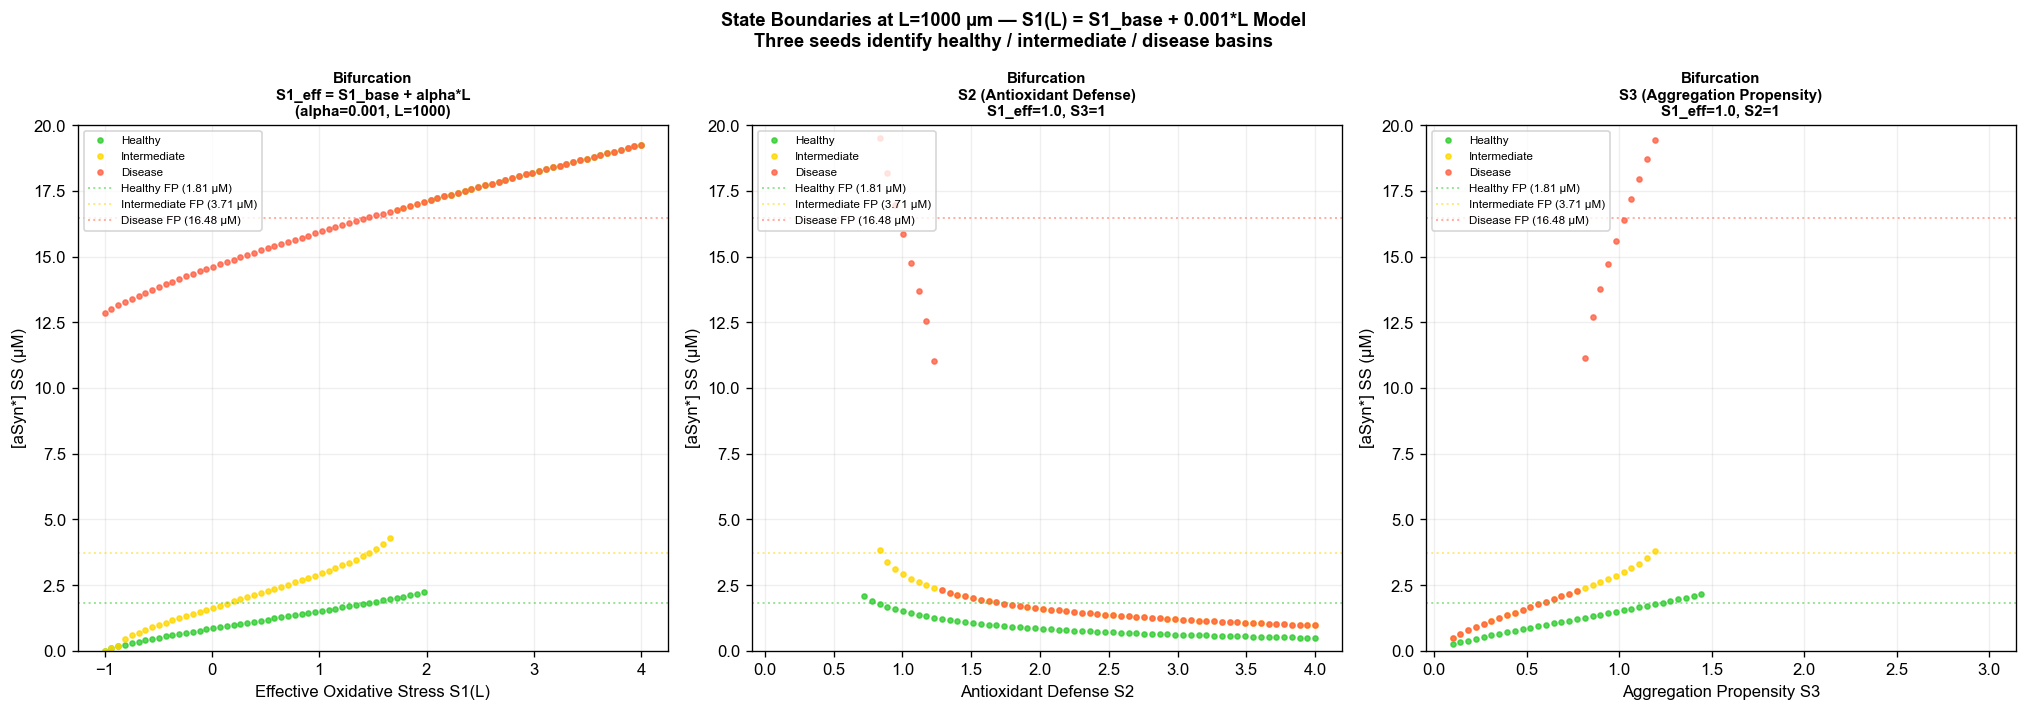

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(17, 6))

sweep_configs = [
    (axes[0], S1_eff_vals, results_S1,
     'S1_eff = S1_base + alpha*L\n(alpha=0.001, L=1000)',
     'Effective Oxidative Stress S1(L)'),
    (axes[1], S2_vals, results_S2,
     'S2 (Antioxidant Defense)\nS1_eff=1.0, S3=1',
     'Antioxidant Defense S2'),
    (axes[2], S3_vals, results_S3,
     'S3 (Aggregation Propensity)\nS1_eff=1.0, S2=1',
     'Aggregation Propensity S3'),
]

ic_colors = {
    'Seed→Healthy':       'limegreen',
    'Seed→Intermediate':  'gold',
    'Seed→Disease':       'tomato',
}

for ax, param_vals, results, subtitle, xlabel in sweep_configs:

    for lbl, col in ic_colors.items():
        A_ss = np.array(results[lbl]['A_ss'])
        ax.plot(param_vals, A_ss,
                'o', ms=3, color=col, alpha=0.8,
                label=lbl.replace('Seed→', ''))

    # Draw FP reference lines
    for fp in fps_ref:
        col_fp = {'Healthy':      'limegreen',
                  'Intermediate': 'gold',
                  'Disease':      'tomato'}.get(fp['label'], 'white')
        ax.axhline(fp['A'], color=col_fp, ls=':', lw=1.2,
                   alpha=0.5,
                   label=f'{fp["label"]} FP ({fp["A"]:.2f} µM)')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel('[aSyn*] SS (µM)', fontsize=10)
    ax.set_title(f'Bifurcation\n{subtitle}',
                 fontsize=9, fontweight='bold')
    ax.legend(fontsize=7, loc='upper left')
    ax.set_ylim(0, 20)
    ax.grid(alpha=0.2)

plt.suptitle(
    f'State Boundaries at L={L:.0f} µm '
    f'— S1(L) = S1_base + {ALPHA}*L Model\n'
    f'Three seeds identify healthy / intermediate / disease basins',
    fontsize=11, fontweight='bold'
)
plt.tight_layout()
plt.savefig('state_boundaries_S1L.png', dpi=150, bbox_inches='tight')
plt.show()

In [11]:
print("=" * 75)
print(f"COMPLETE SUMMARY — L={L} µm, S1(L) = S1_base + {ALPHA}*L")
print("=" * 75)

# For each parameter, find the exact range giving each state
for param_name, param_vals, results in [
    ('S1_eff', S1_eff_vals, results_S1),
    ('S2',     S2_vals,     results_S2),
    ('S3',     S3_vals,     results_S3),
]:
    print(f"\n  Varying {param_name}:")
    print(f"  {'Value':>8}  {'A*(low IC)':>12}  "
          f"{'A*(mid IC)':>12}  {'A*(high IC)':>12}  "
          f"{'Regime'}")
    print(f"  {'─'*65}")

    A_H  = fps_ref[0]['A'] if fps_ref else 1.815
    A_I  = fps_ref[1]['A'] if len(fps_ref)>1 else 3.708
    A_D  = fps_ref[2]['A'] if len(fps_ref)>2 else 16.48
    mid1 = (A_H + A_I) / 2
    mid2 = (A_I + A_D) / 2

    prev_regime = None
    for i, val in enumerate(param_vals):
        A_lo = results['Seed→Healthy']['A_ss'][i]
        A_mi = results['Seed→Intermediate']['A_ss'][i]
        A_hi = results['Seed→Disease']['A_ss'][i]

        states = set()
        for A in [A_lo, A_mi, A_hi]:
            if   A < mid1: states.add('H')
            elif A < mid2: states.add('I')
            else:          states.add('D')

        if   states == {'H'}:        regime = 'Monostable Healthy'
        elif states == {'D'}:        regime = 'Monostable Disease'
        elif states == {'H','I','D'}: regime = 'TRISTABLE'
        elif states == {'H','I'}:    regime = 'Bistable H+I'
        elif states == {'H','D'}:    regime = 'Bistable H+D'
        elif states == {'I','D'}:    regime = 'Bistable I+D'
        else:                         regime = f'Mixed {states}'

        # Print only when regime changes or at boundaries
        if regime != prev_regime:
            print(f"  {val:>8.4f}  {A_lo:>12.4f}  "
                  f"{A_mi:>12.4f}  {A_hi:>12.4f}  "
                  f"← {regime}")
            prev_regime = regime

print(f"""
{'='*75}
KEY FINDINGS
{'='*75}

The S1(L) = S1_base + alpha*L formulation ensures that longer axons
experience higher effective oxidative stress. At L=1000 µm with
alpha={ALPHA}, the effective S1 = {S1_of_L(L):.3f}.

Parameter values that produce each state AT L=1000 µm:

  HEALTHY neuron:
    → S1_base < threshold_1   (low oxidative stress baseline)
    → S2 > threshold_S2       (strong antioxidant defense)
    → S3 < threshold_S3       (low genetic aggregation risk)

  INTERMEDIATE neuron (early disease):
    → S1_base near bistable window
    → S2 near 1.0
    → S3 near 1.0

  DISEASE neuron:
    → S1_base > threshold_2   (high oxidative stress)
    → S2 < threshold_S2_low   (impaired antioxidant defense)
    → S3 > threshold_S3_high  (high genetic risk)

These values define the operating points for the axon length
experiment: fix (S1_base, S2, S3) and vary L.
The S1(L) model then creates automatically increasing vulnerability
with axon length, without any additional assumptions.
""")

COMPLETE SUMMARY — L=1000.0 µm, S1(L) = S1_base + 0.001*L

  Varying S1_eff:
     Value    A*(low IC)    A*(mid IC)   A*(high IC)  Regime
  ─────────────────────────────────────────────────────────────────
   -1.0000       -0.0000       -0.0000       12.8667  ← Bistable H+D
    0.8987        1.4320        2.7673       15.7999  ← TRISTABLE
    1.7215        2.0057       16.7854       16.7854  ← Bistable H+D
    2.0380       17.1470       17.1470       17.1470  ← Monostable Disease

  Varying S2:
     Value    A*(low IC)    A*(mid IC)   A*(high IC)  Regime
  ─────────────────────────────────────────────────────────────────
    0.1000      158.8954      158.8954      158.8954  ← Monostable Disease
    0.7217        2.0605       22.7051       22.7051  ← Bistable H+D
    0.8348        1.7724        3.8272       19.5304  ← TRISTABLE
    1.0609        1.4226        2.7359       14.7575  ← Bistable H+D
    1.2870        1.2041        2.2885        2.2885  ← Monostable Healthy

  Varying S3:
  